<a href="https://colab.research.google.com/github/arian-gif/Neurel-Network/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Custom Built Neural Network

## Target NN

##Target

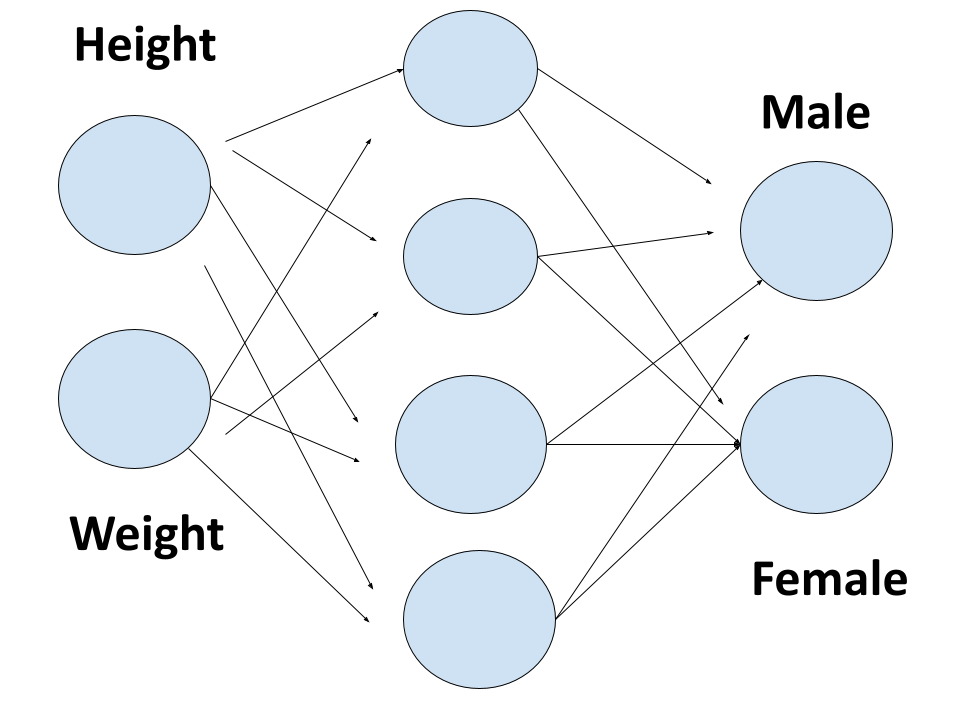

## Preprocessing

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import sympy as sp
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [ ]:
X = np.array([
    [180, 85], [175, 77], [178, 82], [172, 74], [185, 90],
    [177, 79], [181, 88], [169, 72], [176, 80], [183, 92],  # 10 male
    [165, 60], [160, 55], [162, 58], [168, 63], [170, 65],
    [158, 52], [164, 59], [161, 57], [167, 62], [159, 54],  # 10 female
    [182, 86], [174, 76], [179, 84], [171, 73], [184, 91],
    [166, 61], [163, 56], [169, 64], [157, 51], [168, 66]   # 5 male, 5 female
])

y = np.array([[
    "male","male","male","male","male","male","male","male","male","male",   # first 10 = male
    "female","female","female","female","female","female","female","female","female","female",   # next 10 = female
    "male","male","male","male","male",              # 5 more male
    "female","female","female","female","female"              # 5 more female
]])
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Derivation

### Input layer

In [ ]:
def initialize(X, next_layer):
  input_dim = X.shape[1]
  weight_matrix = []
  bias_vector = []

  for i in range(next_layer):
    initial_value =0
    bias_vector.append(initial_value)
    weight_matrix.append(np.random.rand(input_dim))

  weight_matrix = np.array(weight_matrix)
  bias_vector = np.array(bias_vector)
  return weight_matrix, bias_vector


### hidden layer

In [ ]:
def activation(X,weight_matrix,bias_vector,activation_function="relu"):
  z = []
  for i in range(len(X)):
    z.append(np.dot(weight_matrix,X[i]) + bias_vector)
  z = np.array(z)
  if activation_function == "relu":
    return np.maximum(0, z)
  elif activation_function == "sigmoid":
    return 1 / (1 + np.exp(-z))
  elif activation_function == "softmax":
    exp_values = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

### Output layer

### Backpropagation

In [ ]:
def gradient_descent(X_train, y_train, w, b, w2, b2, lr=0.01):
    hidden_layer = activation(X_train, w, b, "relu")
    output_layer = activation(hidden_layer, w2, b2, "softmax")

    loss = cross_entropy_loss(y_train, output_layer)
    m = X_train.shape[0]

    dz2 = output_layer - y_train

    gradient_W2 = np.zeros_like(w2, dtype=float)
    gradient_b2 = np.zeros_like(b2, dtype=float)

    for i in range(m):
        gradient_W2 += np.outer(dz2[i], hidden_layer[i])
        gradient_b2 += dz2[i]

    gradient_W2 /= m
    gradient_b2 /= m

    gradient_W1 = np.zeros_like(w, dtype=float)
    gradient_b1 = np.zeros_like(b, dtype=float)

    for i in range(m):
        dz1 = np.dot(w2.T, dz2[i]) * (hidden_layer[i] > 0).astype(float)

        gradient_W1 += np.outer(dz1, X_train[i])
        gradient_b1 += dz1

    gradient_W1 /= m
    gradient_b1 /= m

    new_W1 = w - lr * gradient_W1
    new_b1 = b - lr * gradient_b1
    new_W2 = w2 - lr * gradient_W2
    new_b2 = b2 - lr * gradient_b2

    return new_W1, new_b1, new_W2, new_b2

def cross_entropy_loss(y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(np.sum(y_true * np.log(y_pred_clipped), axis=1))

def backpropagation(X_train, y_train, output, weight_matrix, bias_vector, weight_matrix2, bias_vector2):
    loss_function = cross_entropy_loss(y_train, output)
    new_weight_matrix, new_bias_vector, new_weight_matrix2, new_bias_vector2 = gradient_descent(
        X_train, y_train, weight_matrix, bias_vector, weight_matrix2, bias_vector2
    )
    return new_weight_matrix, new_bias_vector, new_weight_matrix2, new_bias_vector2, loss_function

In [ ]:
epochs = 100
loss_history = []

for epoch in range(epochs):
    hidden_layer = activation(X_train, weight_matrix, bias_vector, "relu")
    output = activation(hidden_layer, weight_matrix2, bias_vector2, "softmax")
    weight_matrix, bias_vector, weight_matrix2, bias_vector2, loss_function = backpropagation(
        X_train, y_train, output, weight_matrix, bias_vector, weight_matrix2, bias_vector2
    )
    loss_history.append(loss_function)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss_function:.4f}")

hidden_layer_test = activation(X_test, weight_matrix, bias_vector, "relu")
output_test = activation(hidden_layer_test, weight_matrix2, bias_vector2, "softmax")

predictions = np.argmax(output_test, axis=1)
actual = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == actual)
print(f"\nFinal Training Loss: {loss_history[-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Predictions: {predictions}")
print(f"Actual:      {actual}")

Epoch 0, Loss: 0.3380
Epoch 20, Loss: 0.3271
Epoch 40, Loss: 0.3167
Epoch 60, Loss: 0.3069
Epoch 80, Loss: 0.2978

Final Training Loss: 0.2899
Test Accuracy: 1.0000
Predictions: [0 0 1 0 1 1]
Actual:      [0 0 1 0 1 1]
